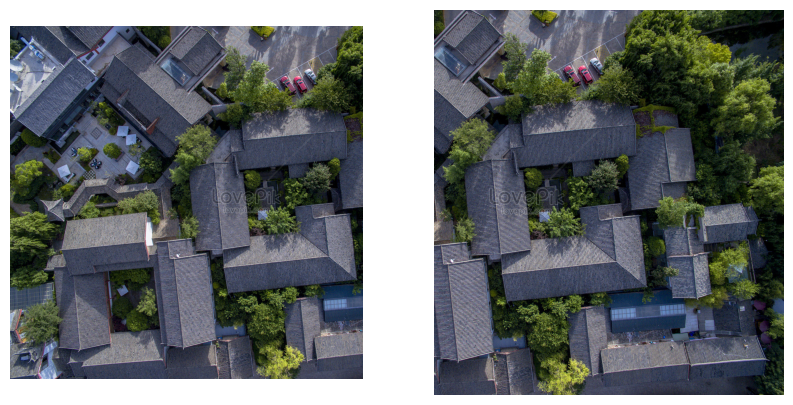

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img1 = cv2.imread('data/images_1.png')
img2 = cv2.imread('data/images_2.png')

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img1)
axs[0].axis('off')
axs[1].imshow(img2)
axs[1].axis('off')
plt.show()

In [3]:
from scipy import ndimage as ndi

def harris_corner_detector(image: np.ndarray, w: int, kappa: float, threshold_ratio: float = 0.01):

    if image.ndim == 3:
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    elif image.ndim == 2:
        gray_image = image
    else:
        raise ValueError("Input image must be 2D (grayscale) or 3D (BGR/RGB).")

    img_float = gray_image.astype(np.float64)

    # Step 1: Optional initial smoothing (common practice)
    # Use an odd kernel size for GaussianBlur
    smooth_ksize = w if w % 2 != 0 else w + 1
    img_smoothed = cv2.GaussianBlur(img_float, (smooth_ksize, smooth_ksize), sigmaX=1.0)

    # Step 2: Calculate gradients Ix, Iy
    # Using cv2.Sobel with ksize=3 is common, matches description's intent
    Ix = cv2.Sobel(img_smoothed, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(img_smoothed, cv2.CV_64F, 0, 1, ksize=3)

    # Step 3: Calculate products and apply Gaussian windowing
    Ix2 = Ix * Ix
    Iy2 = Iy * Iy
    Ixy = Ix * Iy

    # The sums in the Harris matrix H correspond to windowed sums,
    # often implemented by Gaussian filtering the gradient products.
    # Use the specified window size w for the Gaussian kernel.
    window_ksize = w if w % 2 != 0 else w + 1
    # Sigma often related to window size, e.g., sigma = window_ksize / 5.0 or similar
    sigma_window = window_ksize / 5.0

    A = cv2.GaussianBlur(Ix2, (window_ksize, window_ksize), sigmaX=sigma_window)
    B = cv2.GaussianBlur(Iy2, (window_ksize, window_ksize), sigmaX=sigma_window)
    C = cv2.GaussianBlur(Ixy, (window_ksize, window_ksize), sigmaX=sigma_window)

    # Calculate Harris response K = det(H) - kappa * trace(H)^2
    detH = A * B - C * C
    traceH = A + B
    K = detH - kappa * (traceH * traceH)

    # Step 4: Thresholding
    # Use a threshold relative to the max response
    threshold = threshold_ratio * K.max()
    thresholded_mask = K > threshold

    # Step 5: Non-Maximum Suppression (NMS)
    # Find local maxima in a w x w neighborhood
    nms_window_size = w
    local_maxima_mask = (K == ndi.maximum_filter(K, size=nms_window_size, mode='reflect'))

    # Combine thresholding and NMS
    corner_mask = thresholded_mask & local_maxima_mask

    # Get coordinates of the final keypoints (corners)
    # np.argwhere returns (row, col) which is (y, x) in image coordinates
    keypoints = np.argwhere(corner_mask)

    return keypoints

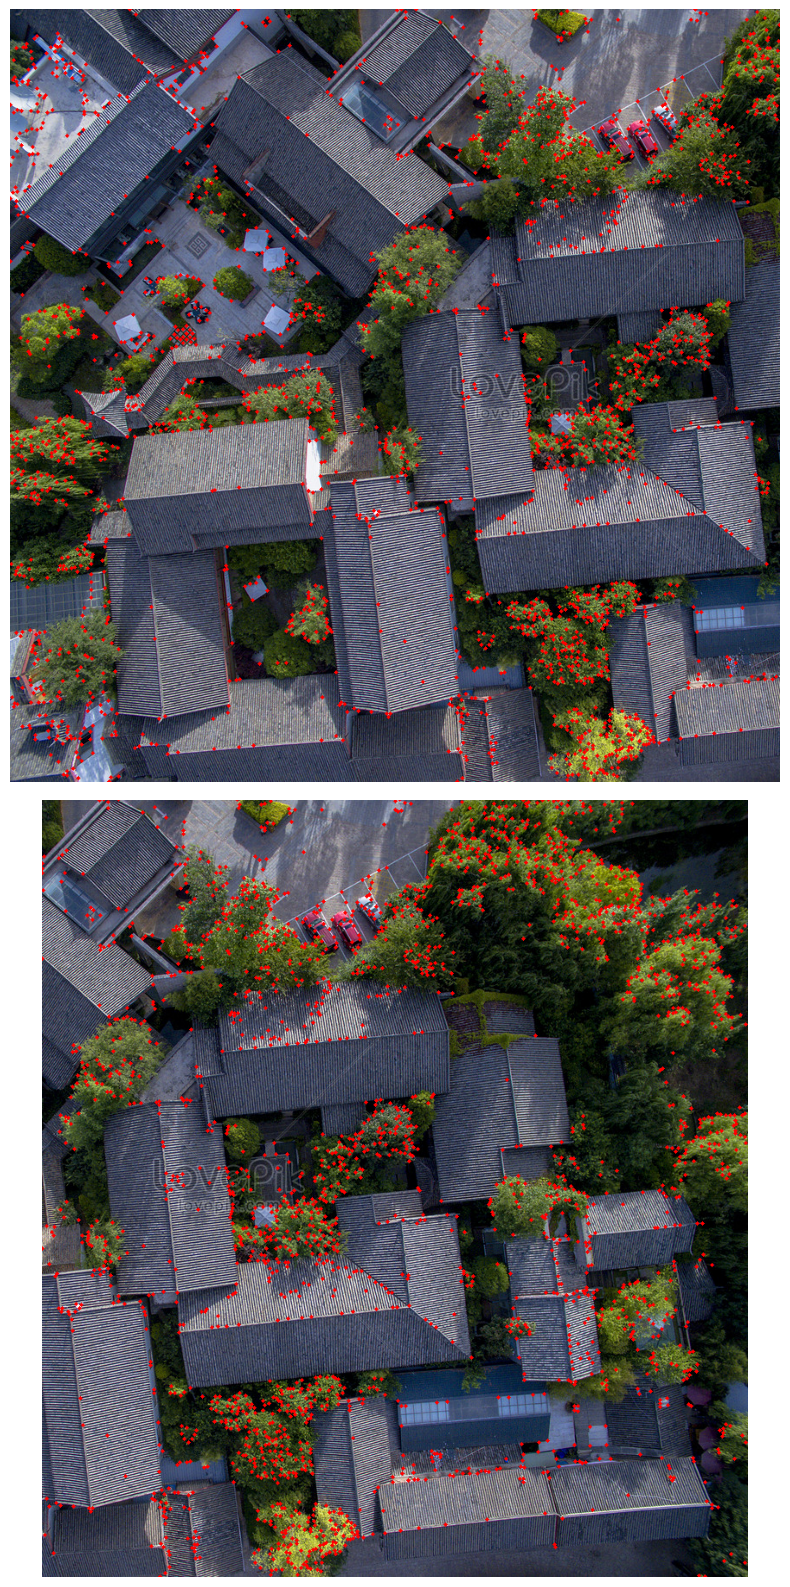

In [4]:
def draw_keypoints(image, keypoints, color=(255, 0, 0)):
    img_copy = image.copy()
    for y, x in keypoints:
        cv2.circle(img_copy, (x, y), 2, color, -1)
    return img_copy

kp1 = harris_corner_detector(img1, w=5, kappa=0.04)
kp2 = harris_corner_detector(img2, w=5, kappa=0.04)

img1_corners = draw_keypoints(img1, kp1)
img2_corners = draw_keypoints(img2, kp2)

fig, axs = plt.subplots(2, 1, figsize=(8, 16))
axs[0].imshow(img1_corners)
axs[0].axis('off')
axs[1].imshow(img2_corners)
axs[1].axis('off')
plt.tight_layout()
plt.show()

In [5]:
def features(image: np.ndarray, keypoints: np.ndarray) -> np.ndarray:
    if image.ndim == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image.copy()

    descriptors = []
    pad = 4
    padded = np.pad(gray, pad, mode='constant')

    for y, x in keypoints:
        patch = padded[y:y+9, x:x+9]
        if patch.shape == (9, 9):
            descriptors.append(patch.flatten())

    return np.array(descriptors)

desc1 = features(img1, kp1)
desc2 = features(img2, kp2)
print(f"Descriptors from image 1: {desc1.shape}")
print(f"Descriptors from image 2: {desc2.shape}")

Descriptors from image 1: (2240, 81)
Descriptors from image 2: (2328, 81)


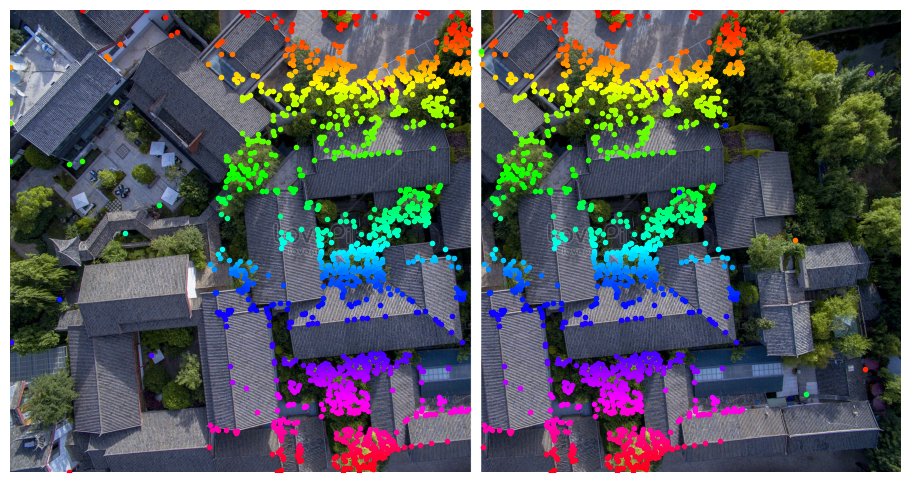

In [9]:
def matching(descriptors1: np.ndarray, descriptors2: np.ndarray, tau: float) -> np.ndarray:
    matches = -np.ones(len(descriptors1), dtype=int)
    for i, d1 in enumerate(descriptors1):
        dists = np.sum((descriptors2 - d1) ** 2, axis=1)
        min_idx = np.argmin(dists)
        if dists[min_idx] < tau:
            matches[i] = min_idx
    return matches

matches = matching(desc1, desc2, tau=5000)

gap = 20
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]
h = max(h1, h2)
w = w1 + w2 + gap

matched_img = np.ones((h, w, 3), dtype=np.uint8) * 255
matched_img[:h1, :w1] = img1
matched_img[:h2, w1 + gap:] = img2

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(matched_img)
ax.axis('off')

colors = plt.cm.hsv(np.linspace(0, 1, len(kp1)))

for i, m in enumerate(matches):
    if m != -1:
        pt1 = (kp1[i][1], kp1[i][0])
        pt2 = (kp2[m][1] + w1 + gap, kp2[m][0])
        color = colors[i]
        ax.plot(pt1[0], pt1[1], marker='o', color=color, markersize=3)
        ax.plot(pt2[0], pt2[1], marker='o', color=color, markersize=3)

plt.show()